# **Student Academic Performance in Ethiopia: Prediction, Key Drivers, and Statistical Insights**

Using 100,000 student records to uncover how environment, school quality, and student behaviour shape academic success.

---

### 📌 Author
Christian Bisrat

### 🛠 Tools Used
Python • Pandas • NumPy • Scikit-Learn • SciPy • Matplotlib • Google Colab

### 📅 Project Type
Machine Learning | Statistical Analysis | Education Analytics

---

### Background

Student success is often explained through assumptions:

- “Some schools are better.”
- “Family background matters most.”
- “Students just need to work harder.”

But what does the data actually say?

As a former Ethiopian Grade 12 entrance exam student, I personally experienced the stress and uncertainty surrounding academic performance. This project was inspired by a simple but important question:

> **What truly affects student performance in Ethiopia?**

To answer this, I used data science methods to analyze a large Ethiopian student dataset and measure the influence of contextual, institutional, and behavioural factors.

---

### 🎯 Main Objectives

This project investigates:

- Can student performance be predicted accurately?
- Which factors matter most?
- Do school resources outperform family background?
- Does student behaviour improve predictions?
- Are differences across gender, region, and school type statistically significant?

---

### 📂 Dataset Overview

- **Source:** Ethiopian Students Dataset (Kaggle)
- **Records:** 100,000 students
- **Original Variables:** 634 columns
- **Final Analytical Dataset:** Cleaned and reduced feature set

The dataset employed here is a **simulated version of a real Ethiopian education dataset**, specifically crafted to reflect the characteristics and challenges of actual student records. Real government data of this nature is confidential and inaccessible, making this simulated dataset an invaluable resource for this study.The raw dataset is a vary rich data covering demographics, parental background, school characteristics, attendance, homework, and national examination results.

---

### Workflow Roadmap

This notebook is structured into the following sections:

1️⃣ Data Loading & Inspection
Understand dataset size, structure, missing values, and variable types.

2️⃣ Data Cleaning & Preprocessing
Encoding, feature selection, leakage prevention, missing value treatment.

3️⃣ Exploratory Data Analysis
Target distributions, descriptive statistics, correlations, Linear Regression Baseline.

4️⃣ Model 1: Contextual Prediction
Predict performance using background + school variables only.

5️⃣ Model 2: Context + Behaviour Prediction
Add attendance, homework, participation, engagement metrics.

6️⃣ Hypothesis Testing
ANOVA and t-tests for group differences.

7️⃣ Final Insights & Educational Implications

---

### Key Question

> Is success driven more by opportunity… or by engagement?

Let the data answer.

---

## **1. Import Libraries**

The following libraries are used for data handling, visualization, machine learning, and statistical testing.

In [1]:
import importlib
import subprocess
import sys

required_packages = {
    "pandas": "pandas",
    "numpy": "numpy",
    "matplotlib": "matplotlib",
    "seaborn": "seaborn",
    "sklearn": "scikit-learn",
    "scipy": "scipy",
    "gdown": "gdown",
}

for module_name, package_name in required_packages.items():
    try:
        importlib.import_module(module_name)
    except ImportError:
        subprocess.check_call([sys.executable, "-m", "pip", "install", package_name])

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression, LogisticRegression
from sklearn.metrics import mean_squared_error, r2_score, accuracy_score
from scipy import stats

## **2. Load Dataset**

The dataset is loaded from Google Drive for efficient access and to avoid repeated uploads, as the dataset is too large to upload to GitHub.

In [ ]:
# gdown is installed in the setup cell above when needed.

In [3]:
import gdown

In [4]:
from pathlib import Path

dataset_path = Path("ethiopian_students_dataset.zip")

if not dataset_path.exists():
    file_id = "1oNaD_vzPsztoP8KelpKl06ysEd-stBZ_"
    url = f"https://drive.google.com/uc?id={file_id}"
    gdown.download(url, str(dataset_path), quiet=False)
else:
    print(f"Dataset already exists at: {dataset_path.resolve()}")

Downloading...
From (original): https://drive.google.com/uc?id=1oNaD_vzPsztoP8KelpKl06ysEd-stBZ_
From (redirected): https://drive.google.com/uc?id=1oNaD_vzPsztoP8KelpKl06ysEd-stBZ_&confirm=t&uuid=8770a020-900c-4853-acda-2e91caa72835
To: /content/ethiopian_students_dataset.zip
100%|██████████| 121M/121M [00:00<00:00, 130MB/s]


In [5]:
if not dataset_path.exists():
    raise FileNotFoundError(
        "ethiopian_students_dataset.zip was not found. Run the download cell above or place the zip file next to this notebook."
    )

df = pd.read_csv(dataset_path, compression="zip")

print("Dataset Loaded Successfully")
print("Shape:", df.shape)

Dataset Loaded Successfully
Shape: (100000, 634)


## **3. Preview Dataset**

We inspect the first rows and basic structure of the dataset.

In [6]:
df.head()

,Student_ID,Gender,Date_of_Birth,Region,Health_Issue,Grade_Level,Father_Education,Mother_Education,Parental_Involvement,Home_Internet_Access,...,National_Exam_Geography,National_Exam_Economics,National_Exam_Math_Social,National_Exam_Biology,National_Exam_Chemistry,National_Exam_Physics,National_Exam_Math_Natural,Total_Test_Score,Overall_Average,Total_National_Exam_Score
0,133604e6-8cd7-4e16-b669-46ff22af1605,Male,18/06/2006,Tigray,Vision Issues,12,NaN,High School,0.56,No,...,NaN,NaN,NaN,52.46,28.47,32.12,54.60,5411.88,49.20,287.71
1,16f0b607-2bda-4ba7-8d8f-ba7034ace507,Female,26/07/2007,Dire Dawa,Parasitic Infections,12,High School,NaN,0.53,Yes,...,NaN,NaN,NaN,48.80,48.80,46.07,48.80,6319.97,57.45,323.47
2,90da8386-6a96-4c4c-89bc-5ea9ebec0aa8,Male,22/01/2007,Afar,NaN,12,Primary,College,0.45,No,...,NaN,NaN,NaN,47.10,47.10,26.42,37.65,5997.12,54.52,281.11
3,54fdef19-925e-4b30-b573-f2a96de7ea7f,Female,13/10/2007,Sidama,NaN,12,College,High School,0.80,No,...,53.64,53.64,42.4,NaN,NaN,NaN,NaN,6935.94,64.22,353.63
4,81fb7eb6-74fc-4abc-b2e3-f740ed89f77a,Male,15/04/2007,Gambela,NaN,12,Primary,Primary,0.24,Yes,...,NaN,NaN,NaN,53.21,53.21,53.21,49.09,5403.61,49.12,346.76


In [7]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 100000 entries, 0 to 99999
Columns: 634 entries, Student_ID to Total_National_Exam_Score
dtypes: float64(499), int64(1), object(134)
memory usage: 483.7+ MB


### **Dataset Structure Summary**

This section presents a summary of the dataset's variables and their corresponding data types. The `head()` method is utilized to display the initial entries for conciseness; this parameter can be adjusted to inspect a broader range of variables.

In [8]:
import os

out_dir = "ML_Project_Results"
os.makedirs(out_dir, exist_ok=True)

print("Output folder ready:", out_dir)

Output folder ready: ML_Project_Results


In [9]:
# Column names and data types
structure_table = pd.DataFrame({
    "Variable": df.columns,
    "Class": df.dtypes.astype(str).values
})

# Save structure table
structure_table.to_csv(f"{out_dir}/dataset_structure.csv", index=False)

structure_table.head(5)

,Variable,Class
0,Student_ID,object
1,Gender,object
2,Date_of_Birth,object
3,Region,object
4,Health_Issue,object


### **Variable Type Counts**

This shows how many variables belong to each data type.

In [10]:
class_summary = structure_table["Class"].value_counts().reset_index()
class_summary.columns = ["Class", "Count"]

print(class_summary)

# Save summary
class_summary.to_csv(f"{out_dir}/dataset_class_summary.csv", index=False)

     Class  Count
0  float64    499
1   object    134
2    int64      1


The dataset contains predominantly numerical variables (499 float features), with a substantial number of categorical variables (134), requiring encoding prior to modeling.

##**4. Missing Value Audit**

This section evaluates missing values across all variables to understand data quality and identify columns requiring cleaning.

In [11]:
# Missing values summary
missing_count = df.isnull().sum()
missing_percent = (df.isnull().mean() * 100)

missing_table = pd.DataFrame({
    "Variable": df.columns,
    "MissingCount": missing_count.values,
    "MissingPercent": missing_percent.values
})

missing_table = missing_table.sort_values(
    by="MissingPercent",
    ascending=False
)

missing_table.head(20)

,Variable,MissingCount,MissingPercent
4,Health_Issue,79521,79.521
628,National_Exam_Chemistry,50257,50.257
629,National_Exam_Physics,50257,50.257
586,Grade_12_Chemistry_Attendance,50257,50.257
630,National_Exam_Math_Natural,50257,50.257
588,Grade_12_Chemistry_Class_Participation,50257,50.257
589,Grade_12_Chemistry_Textbook,50257,50.257
590,Grade_12_Physics_Test_Score,50257,50.257
587,Grade_12_Chemistry_Homework_Completion,50257,50.257
591,Grade_12_Physics_Attendance,50257,50.257


In [17]:
missing_table.to_csv(f"{out_dir}/missingness_all_variables.csv", index=False)

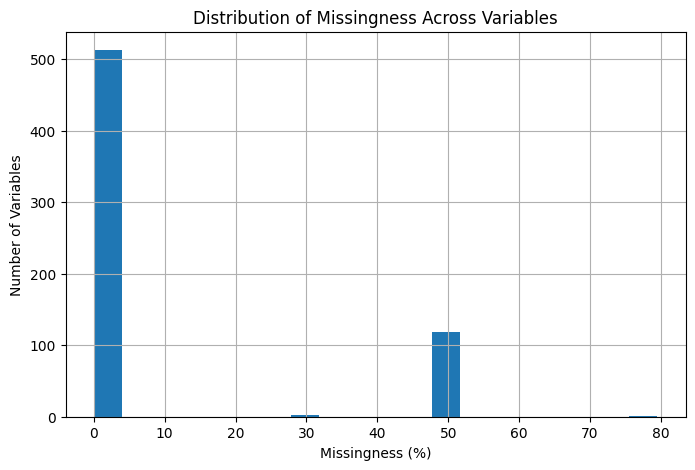

In [18]:
plt.figure(figsize=(8,5))
plt.hist(missing_table["MissingPercent"], bins=20)
plt.xlabel("Missingness (%)")
plt.ylabel("Number of Variables")
plt.title("Distribution of Missingness Across Variables")
plt.grid(True)
plt.show()

The histogram shows the percentage of missing values across all variables in the original dataset. A very large concentration of variables appears near **0% missingness**, indicating that most variables are complete and contain usable information. This suggests that the dataset has a generally strong data quality foundation.

A second noticeable cluster appears around **50% missingness**, meaning a substantial group of variables have approximately half of their values missing. This pattern is unlikely to be random and instead suggests **structural missingness**. In this dataset, many variables are repeated across grades and subject streams, so certain columns may only apply to specific groups of students (for example, Grade 11 or subject-specific pathways). Therefore, the missing values likely reflect conditional applicability rather than poor data collection.

The table also reveals that the 'Health_Issue' variable has nearly 80% missing values. It is highly probable that these missing values signify the absence of a reported health issue for the student. Consequently, missing values in the 'Health_Issue' variable will be imputed with 'No health issue,' as it is unlikely that these represent a specific health condition that could be filled by the mode.

There are also a very small number of variables with moderate or high missingness outside these clusters, but they are limited in number.

Overall, the graph indicates that the dataset does not suffer from widespread random missing data. Instead, missingness is concentrated in specific variable groups created by the structure of the educational system represented in the dataset. This supports the decision to reduce the dataset and focus on independent contextual variables with complete or near-complete information before modelling.

## **5. Defining Target and predictor Variables**

In supervised machine learning, target variables are the outcomes the model aims to predict. In this project, three academic performance indicators are selected as targets: **Total Test Score**, **Overall Average**, and **Total National Examination Score**. Each target will be analysed separately to understand how different factors influence various dimensions of student achivment.

In [16]:
target_names = [
    "Total_Test_Score",
    "Overall_Average",
    "Total_National_Exam_Score"
]

# Check if targets exist
for col in target_names:
    if col not in df.columns:
        print("Missing target:", col)

Predictor variables are the input features used to explain or predict the selected outcomes. For Model 1, only **independent contextual variables** are included. These variables represent student background, family conditions, school characteristics, and access to educational resources. Variables directly related to academic scores or grade-level performance are excluded to avoid data leakage and preserve interpretability.

It is important to note that many features are systematically generated across grades and subjects, leading to a highly structured but interdependent data space. In particular, grade-level test scores and national examination subject scores directly contribute to aggregate performance indicators such as total test score, overall average, and total national examination score. Including such variables as predictors would introduce data leakage, resulting in artificially inflated model performance and loss of interpretability.

In [15]:
predictor_names = [
    "Gender",
    "Date_of_Birth",
    "Region",
    "Health_Issue",
    "Father_Education",
    "Mother_Education",
    "Parental_Involvement",
    "Home_Internet_Access",
    "Electricity_Access",
    "School_Type",
    "School_Location",
    "Teacher_Student_Ratio",
    "School_Resources_Score",
    "Student_to_Resources_Ratio",
    "School_Academic_Score"
]

missing_predictors = [col for col in predictor_names if col not in df.columns]

print("Missing predictors:", missing_predictors)

Missing predictors: []


## **6.Building the Reduced Analysis Dataset**

To improve interpretability and computational efficiency, a reduced dataset is constructed using only the selected predictor variables and target variables. This removes unnecessary high-dimensional features while preserving the most relevant contextual and academic information for modelling.

In [20]:
# Build reduced dataset
D = df[predictor_names + target_names].copy()

print("="*50)
print("REDUCED ANALYSIS DATASET")
print("="*50)
print("Selected predictors:", len(predictor_names))
print("Targets            :", len(target_names))
print("Total variables    :", D.shape[1])

REDUCED ANALYSIS DATASET
Selected predictors: 15
Targets            : 3
Total variables    : 18


## **7. Data Preprocessing**

The reduced dataset is preprocessed to make it suitable for machine learning. This includes transforming dates into age, encoding categorical variables, converting binary features into numerical form, and ensuring all variables are numeric.

In [22]:
from datetime import datetime

# Date_of_Birth -> Age
if "Date_of_Birth" in D.columns:
    D["Date_of_Birth"] = pd.to_datetime(D["Date_of_Birth"], errors="coerce")

    today = pd.Timestamp.today()
    D["Age"] = (today - D["Date_of_Birth"]).dt.days / 365.25

    D.drop(columns=["Date_of_Birth"], inplace=True)
    predictor_names = [col for col in predictor_names if col != "Date_of_Birth"]
if "Age" not in predictor_names:
    predictor_names.append("Age")

/tmp/ipykernel_6545/3443804744.py:5: UserWarning: Parsing dates in %d/%m/%Y format when dayfirst=False (the default) was specified. Pass `dayfirst=True` or specify a format to silence this warning.
  D["Date_of_Birth"] = pd.to_datetime(D["Date_of_Birth"], errors="coerce")


In [23]:
binary_vars = ["Home_Internet_Access", "Electricity_Access"]

for col in binary_vars:
    if col in D.columns:
        D[col] = D[col].astype(str).str.lower().map({
            "yes":1,
            "no":0,
            "true":1,
            "false":0
        })

In [24]:
# Impute 'Health_Issue' missing values with 'No health issue' in D
# This should happen before converting to categorical codes
if 'Health_Issue' in D.columns:
    # First, convert column to object type to allow string assignment for 'No health issue'
    D['Health_Issue'] = D['Health_Issue'].astype(str)
    D['Health_Issue'] = D['Health_Issue'].fillna('No health issue')
    # Replace 'nan' string (if any were converted to string before fillna) with 'No health issue'
    D['Health_Issue'] = D['Health_Issue'].replace('nan', 'No health issue')

print("Health_Issue imputed successfully.")

Health_Issue imputed successfully.


In [25]:
print("Unique values in Father_Education before encoding:", D['Father_Education'].unique())
print("Unique values in Mother_Education before encoding:", D['Mother_Education'].unique())


Unique values in Father_Education before encoding: [nan 'High School' 'Primary' 'College' 'University']
Unique values in Mother_Education before encoding: ['High School' nan 'College' 'Primary' 'University']


In [26]:
#Define the logical order
edu_order = ['Primary', 'High School','College' ,'University']

#Convert to categorical with the specific order within the D DataFrame
if 'Father_Education' in D.columns:
    D['Father_Education'] = pd.Categorical(D['Father_Education'], categories=edu_order, ordered=True)
    D['Father_Education'] = D['Father_Education'].cat.codes

if 'Mother_Education' in D.columns:
    D['Mother_Education'] = pd.Categorical(D['Mother_Education'], categories=edu_order, ordered=True)
    D['Mother_Education'] = D['Mother_Education'].cat.codes


In [27]:
cat_cols = [
    "Gender",
    "Region",
    "School_Type",
    "School_Location",
    "Health_Issue"
]

for col in cat_cols:
    if col in D.columns:
        D[col] = D[col].astype("category").cat.codes


In [28]:
# Convert everything possible to numeric
for col in D.columns:
    D[col] = pd.to_numeric(D[col], errors="coerce")

D.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 100000 entries, 0 to 99999
Data columns (total 18 columns):
 #   Column                      Non-Null Count   Dtype  
---  ------                      --------------   -----  
 0   Gender                      100000 non-null  int8   
 1   Region                      100000 non-null  int8   
 2   Health_Issue                100000 non-null  int8   
 3   Father_Education            100000 non-null  int8   
 4   Mother_Education            100000 non-null  int8   
 5   Parental_Involvement        100000 non-null  float64
 6   Home_Internet_Access        100000 non-null  int64  
 7   Electricity_Access          100000 non-null  int64  
 8   School_Type                 100000 non-null  int8   
 9   School_Location             100000 non-null  int8   
 10  Teacher_Student_Ratio       100000 non-null  float64
 11  School_Resources_Score      100000 non-null  float64
 12  Student_to_Resources_Ratio  100000 non-null  float64
 13  School_Academic

In [29]:
# Re-define predictor_names based on the final D columns, excluding target_names
predictor_names = [col for col in D.columns if col not in target_names]

print("Updated predictor_names:", predictor_names)

Updated predictor_names: ['Gender', 'Region', 'Health_Issue', 'Father_Education', 'Mother_Education', 'Parental_Involvement', 'Home_Internet_Access', 'Electricity_Access', 'School_Type', 'School_Location', 'Teacher_Student_Ratio', 'School_Resources_Score', 'Student_to_Resources_Ratio', 'School_Academic_Score', 'Age']


As we can see there are no missing values so we move on to our next step.

## **8. Target Variable Descriptive Statistics**

Summary statistics and distributions of the target variables are computed to understand the range and variability of academic performance outcomes.

In [30]:
import matplotlib.pyplot as plt

predictor_summary = []

for col in predictor_names:
    y = D[col]

    summary = {
        "Target": col,
        "N": y.notna().sum(),
        "Mean": y.mean(),
        "Std": y.std(),
        "Min": y.min(),
        "Max": y.max()
    }

    predictor_summary.append(summary)

predictor_summary = pd.DataFrame(predictor_summary)
predictor_summary

,Target,N,Mean,Std,Min,Max
0,Gender,100000,0.501270,0.500001,0.000000,1.000000
1,Region,100000,5.657290,3.663661,0.000000,12.000000
2,Health_Issue,100000,5.082730,1.465315,0.000000,9.000000
3,Father_Education,100000,0.241840,1.060851,-1.000000,3.000000
4,Mother_Education,100000,0.238640,1.064529,-1.000000,3.000000
5,Parental_Involvement,100000,0.386751,0.212878,0.000000,1.000000
6,Home_Internet_Access,100000,0.258300,0.437702,0.000000,1.000000
7,Electricity_Access,100000,0.376880,0.484607,0.000000,1.000000
8,School_Type,100000,3.365220,1.191641,0.000000,4.000000
9,School_Location,100000,0.278840,0.448431,0.000000,1.000000


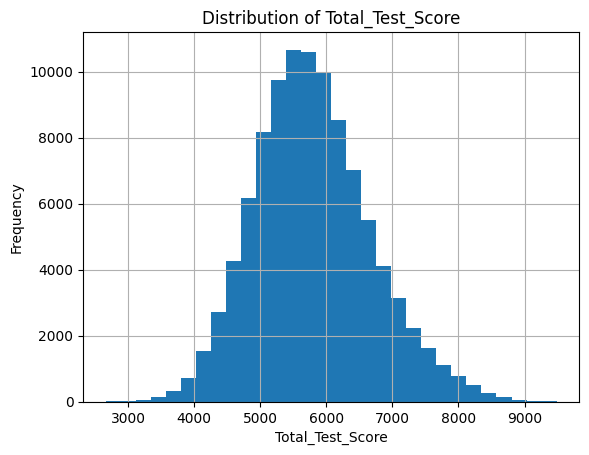

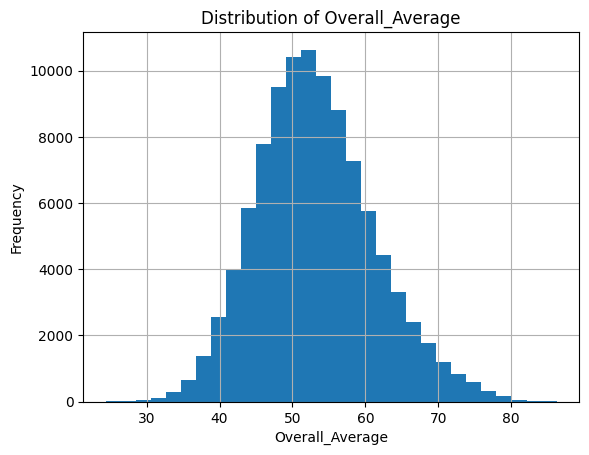

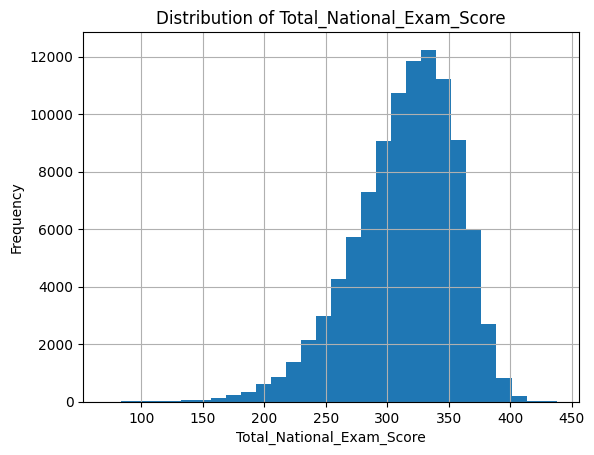

,Target,N,Mean,Std,Min,Max
0,Total_Test_Score,100000,5797.642162,880.669535,2660.93,9485.42
1,Overall_Average,100000,53.193015,8.072334,24.39,86.23
2,Total_National_Exam_Score,100000,314.635244,41.815212,70.90,437.64


In [31]:
import matplotlib.pyplot as plt

target_summary = []

for col in target_names:
    y = D[col]

    summary = {
        "Target": col,
        "N": y.notna().sum(),
        "Mean": y.mean(),
        "Std": y.std(),
        "Min": y.min(),
        "Max": y.max()
    }

    target_summary.append(summary)

    plt.figure()
    plt.hist(y, bins=30)
    plt.title(f"Distribution of {col}")
    plt.xlabel(col)
    plt.ylabel("Frequency")
    plt.grid(True)
    plt.show()

target_summary = pd.DataFrame(target_summary)
target_summary

The three target variables represent different dimensions of student academic performance: cumulative internal achievement (**Total_Test_Score**), average classroom performance (**Overall_Average**), and standardized national examination outcome (**Total_National_Exam_Score**). Examining their distributions provides important insight into performance patterns across the student population.

#### **1. Total Test Score**

The distribution of **Total_Test_Score** is approximately bell-shaped with a slight right tail, centered around a mean of **5797.6** points. This indicates that most students achieved scores near the middle range, while fewer students obtained very low or exceptionally high cumulative scores. The relatively large standard deviation (**880.7**) shows substantial variation in long-term academic performance across students. This suggests that internal academic achievement differs considerably depending on student and school conditions.

#### **2. Overall Average**

The **Overall_Average** also follows an approximately normal distribution, centered around **53.19**. Most students cluster between roughly 45 and 60, with fewer students at the extremes. The smaller standard deviation (**8.07**) indicates that average scores are more tightly concentrated than total cumulative scores. This suggests that while students differ in cumulative performance, average achievement tends to remain within a narrower range.

#### **3. Total National Exam Score**

The distribution of **Total_National_Exam_Score** is less symmetric and appears moderately left-skewed, with many students concentrated between approximately 280 and 360. The mean score is **314.64**, with a standard deviation of **41.82**. Compared with the other targets, this variable shows a more compressed range, which is expected in standardized national examinations where scoring systems are fixed. The skewness may indicate that a larger share of students perform around the middle-to-upper range while fewer students achieve very low marks.

#### Overall Interpretation

Together, these results show that the dataset contains strong variability in student outcomes, which is valuable for machine learning modelling because variation provides predictive signal. The internal academic measures (**Total_Test_Score** and **Overall_Average**) appear more normally distributed and therefore may be easier to model. In contrast, the national examination score shows a different pattern, suggesting that external standardized exams may be influenced by additional factors such as exam pressure, preparation quality, or subject-specific readiness.

These findings support modelling each target variable separately, since they capture different aspects of academic success and may respond differently to contextual predictors.

## **9. Correlation Screening**

Before machine learning, Pearson correlation analysis is conducted to explore linear associations between predictor variables and each academic performance target.

It is important to note that this type of correlation test is generally not suitable for nominal or categorical data, even when converted to numerical labels (like 'Region', 'School_Type', and 'Health_Issue' using label encoding). This is because Pearson correlation assumes continuous, linearly related variables, and assigning arbitrary numerical values to unordered categories can lead to misleading interpretations. However, to statistically examine whether there are significant differences related to these categorical variables, hypothesis testing will be conducted after the modeling phase.

Nevertheless, these variables are retained in the dataset because the machine learning models used (Random Forest and Gradient Boosting) are robust and can effectively handle such encodings without necessarily assuming a linear relationship. If linear regression were to be used, one-hot encoding would typically be required, which could significantly increase the dimensionality of the dataset and potentially introduce sparsity.

In [32]:
corr_results = []

# Define variables to exclude from Pearson correlation
excluded_correlation_vars = ['Region', 'School_Type', 'Health_Issue']

# Create a filtered list of predictor names for correlation calculation
filtered_predictor_names = [p for p in predictor_names if p not in excluded_correlation_vars]

print(f"Excluding {excluded_correlation_vars} from Pearson correlation table as they are categorical and may produce misleading results.")

for target in target_names:
    for predictor in filtered_predictor_names:
        corr = D[predictor].corr(D[target])
        corr_results.append(
            {
                "Predictor": predictor,
                "Target": target,
                "Correlation": corr
            }
        )

corr_table = pd.DataFrame(corr_results)
corr_table

Excluding ['Region', 'School_Type', 'Health_Issue'] from Pearson correlation table as they are categorical and may produce misleading results.


,Predictor,Target,Correlation
0,Gender,Total_Test_Score,0.000201
1,Father_Education,Total_Test_Score,0.087925
2,Mother_Education,Total_Test_Score,0.091359
3,Parental_Involvement,Total_Test_Score,0.137096
4,Home_Internet_Access,Total_Test_Score,0.049979
5,Electricity_Access,Total_Test_Score,0.038547
6,School_Location,Total_Test_Score,0.414346
7,Teacher_Student_Ratio,Total_Test_Score,-0.242450
8,School_Resources_Score,Total_Test_Score,0.740545
9,Student_to_Resources_Ratio,Total_Test_Score,-0.425883


In [33]:
corr_table.to_csv(f"{out_dir}/feature_target_correlations.csv", index=False)

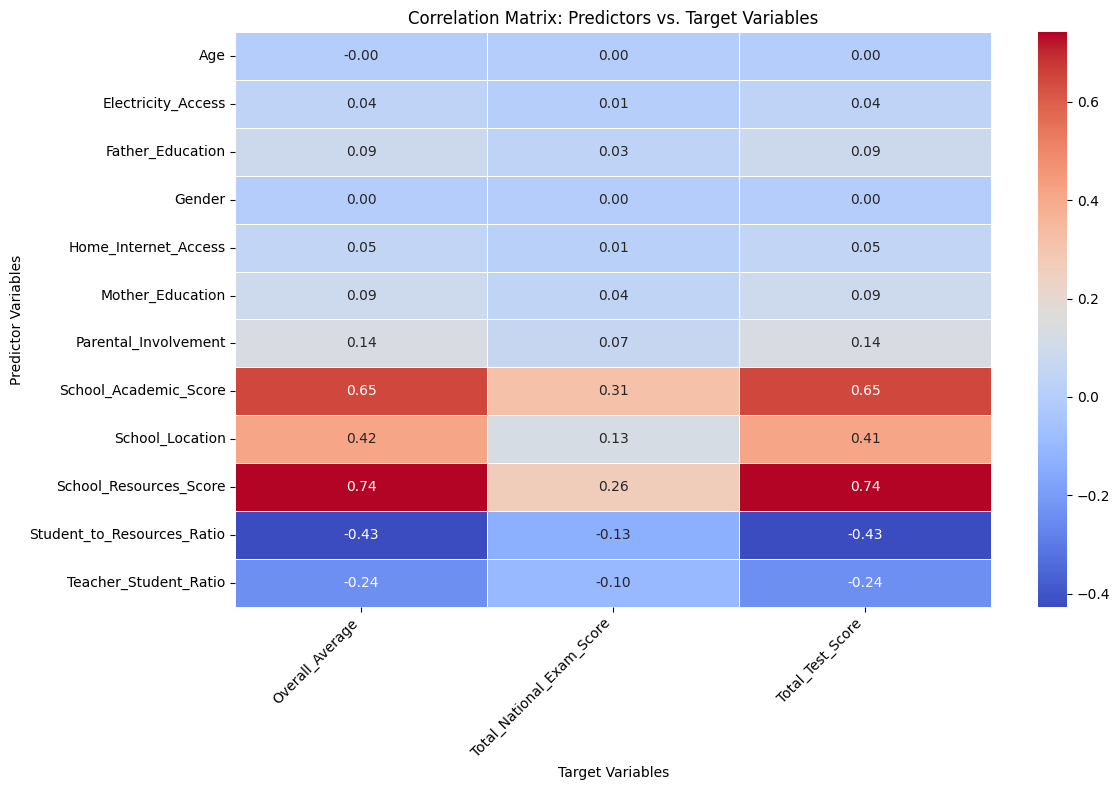

In [34]:
plt.figure(figsize=(12, 8))
correlation_matrix = corr_table.pivot(index='Predictor', columns='Target', values='Correlation')
sns.heatmap(correlation_matrix, annot=True, cmap='coolwarm', fmt=".2f", linewidths=.5)
plt.title('Correlation Matrix: Predictors vs. Target Variables')
plt.xlabel('Target Variables')
plt.ylabel('Predictor Variables')
plt.xticks(rotation=45, ha='right')
plt.yticks(rotation=0)
plt.tight_layout()
plt.show()

This heatmap visually represents the Pearson correlation coefficients between each predictor variable and the three target variables. The color intensity and value indicate the strength and direction of the linear relationship.

*   **Strong Positive Correlations (Red/Orange)**: Variables like `School_Resources_Score` and `School_Academic_Score` show strong positive correlations with `Total_Test_Score` and `Overall_Average`, indicating that higher scores in these predictors are associated with higher academic performance in internal assessments.
*   **Strong Negative Correlations (Blue/Purple)**: `Student_to_Resources_Ratio` and `Teacher_Student_Ratio` show negative correlations, suggesting that as these ratios increase (fewer resources or more students per teacher), academic performance tends to decrease.
*   **Weaker Correlations (Lighter Colors/Near Zero)**: Many other variables, especially `Gender`, `Father_Education`, `Mother_Education`, `Home_Internet_Access`, `Electricity_Access`, and `Age`, show very weak linear correlations across all targets. This indicates that their linear relationship with academic performance is not strong, although they might still have non-linear relationships or interactions captured by models like Random Forest.
*   **Target Variable Differences**: Noticeably, the correlations with `Total_National_Exam_Score` are generally weaker across most predictors compared to `Total_Test_Score` and `Overall_Average`. This justifies the use of a robust model like Random Forest, which can discover these complex, non-linear patterns that simple correlation might miss.

## **10. Modeling**

## Baseline Linear Regression Model

To complement the machine learning models, a baseline **Multiple Linear Regression** model was developed.

Linear regression is a classical statistical method used to estimate the relationship between a continuous target variable and multiple predictors.

Including a linear regression model allows comparison between:

- **Traditional interpretable statistical modelling**
- **Advanced nonlinear machine learning models** such as Random Forest and Gradient Boosting

### Target Variable

The selected target for this baseline model was:

- `Total_National_Exam_Score`

### Purpose

This section helps evaluate whether simple linear relationships are sufficient to explain student performance, or whether more flexible machine learning models provide better predictive accuracy.

In [35]:
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_squared_error, r2_score
import numpy as np

# Predictors
X = D[filtered_predictor_names]

# Target
y = D["Total_National_Exam_Score"]

# Train-test split
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.20, random_state=42
)

# Model
lr = LinearRegression()
lr.fit(X_train, y_train)

# Predictions
y_pred = lr.predict(X_test)

# Metrics
rmse = np.sqrt(mean_squared_error(y_test, y_pred))
r2 = r2_score(y_test, y_pred)

print("Linear Regression Results")
print("Train Size:", len(X_train))
print("Test Size :", len(X_test))
print("RMSE      :", round(rmse,4))
print("R²        :", round(r2,4))

Linear Regression Results
Train Size: 80000
Test Size : 20000
RMSE      : 39.4877
R²        : 0.1071


In [36]:
# Coefficient Table

import pandas as pd

coef_table = pd.DataFrame({
    "Predictor": X.columns,
    "Coefficient": lr.coef_
}).sort_values("Coefficient", ascending=False)

display(coef_table)

,Predictor,Coefficient
10,School_Academic_Score,83.205533
3,Parental_Involvement,12.222872
8,School_Resources_Score,5.289908
11,Age,0.213536
9,Student_to_Resources_Ratio,0.175059
2,Mother_Education,0.157603
1,Father_Education,0.108810
0,Gender,0.071979
7,Teacher_Student_Ratio,-0.008398
4,Home_Internet_Access,-0.089757


A baseline Multiple Linear Regression model was developed to predict `Total_National_Exam_Score` using contextual student, household, and school-level variables.

### Model Performance

- Train Size: **80,000**
- Test Size: **20,000**
- RMSE: **39.49**
- R²: **0.1071**

### Meaning of R² = 0.1071

The model explains approximately **10.7% of the variation** in national examination scores.

This indicates that simple linear relationships between the selected contextual predictors and exam performance are relatively weak.

In other words, most variation in national exam outcomes is influenced by factors not fully captured through a purely linear model.

### Key Predictors (Positive Coefficients)

The strongest positive predictors were:

- **School_Academic_Score** (+83.21)
- **Parental_Involvement** (+12.22)
- **School_Resources_Score** (+5.29)

These results suggest that stronger school academic environment, active parental support, and better school resources are associated with higher national exam performance.

### Smaller Predictors

Variables such as age, parental education, gender, and student-resource ratio had relatively small estimated effects.

### Negative Coefficients

Some predictors showed small negative coefficients, including:

- School_Location
- Electricity_Access
- Home_Internet_Access
- Teacher_Student_Ratio

These values should be interpreted cautiously, especially where variables were encoded numerically or may interact with other predictors.

### Overall Conclusion

Linear regression provided a useful interpretable baseline model but had limited predictive power. The relatively low R² confirms that student academic outcomes are shaped by more than simple linear effects.

This supports the use of more flexible machine learning methods such as Random Forest and Gradient Boosting.

## Model 1: Random Forest Regression

Random Forest was selected because it captures nonlinear relationships and interactions between socioeconomic and school factors.

A Random Forest regression model is trained separately for each target variable using contextual predictors only. Model performance is evaluated using RMSE and R² on a holdout test set.

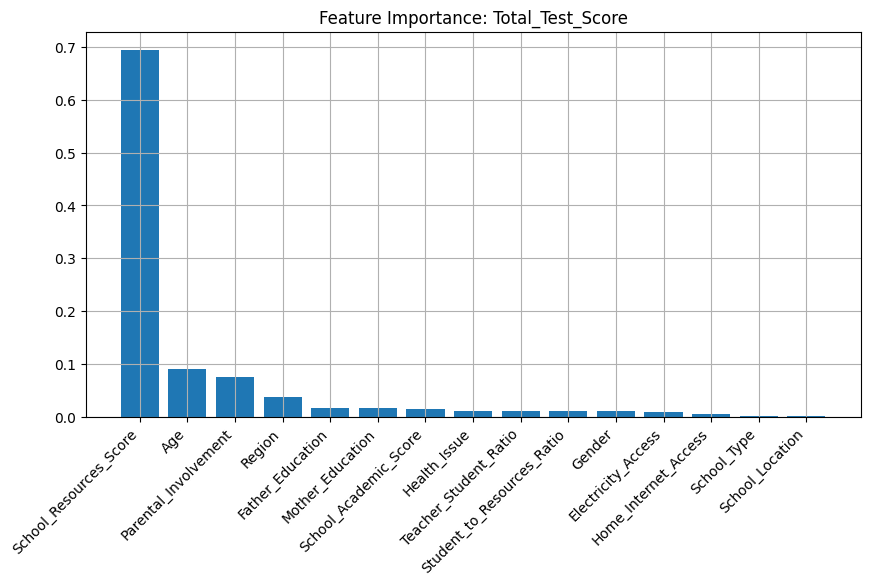

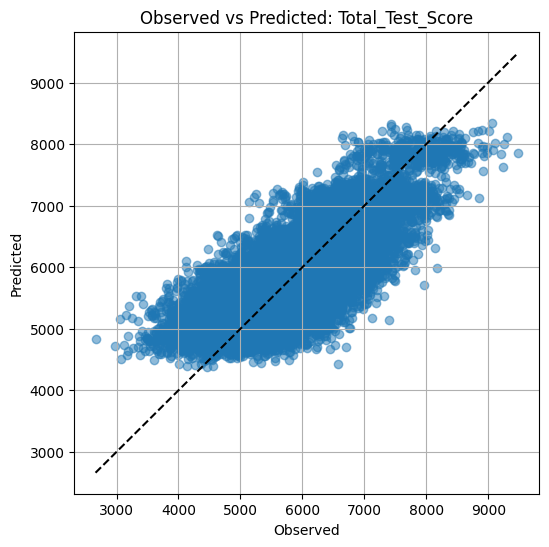

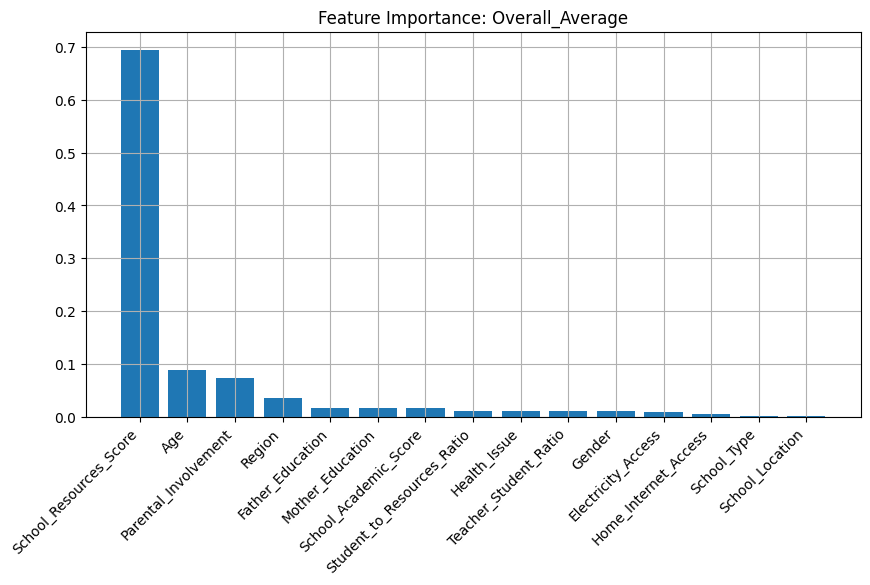

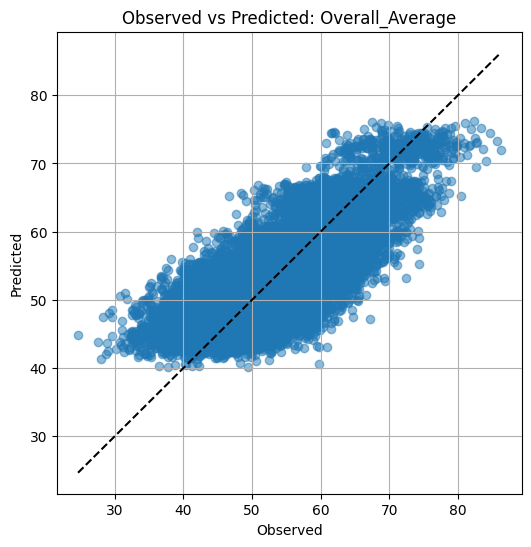

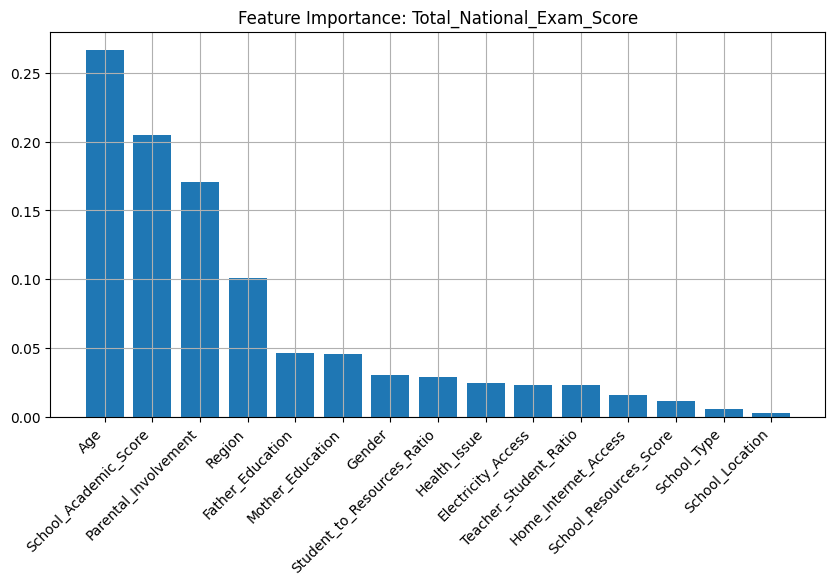

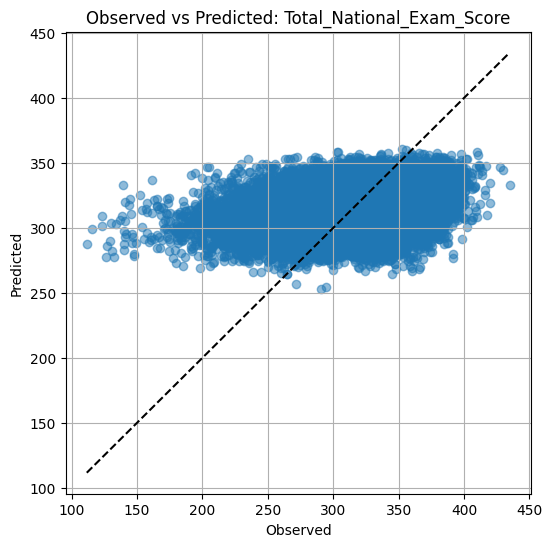

In [37]:
from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import mean_squared_error, r2_score
import numpy as np
import matplotlib.pyplot as plt

n_trees = 200
min_leaf = 5

perf_results = []
importance_all = pd.DataFrame(index=predictor_names)

for target in target_names:

    X = D[predictor_names]
    y = D[target]

    X_train, X_test, y_train, y_test = train_test_split(
        X, y, test_size=0.20, random_state=42
    )

    rf = RandomForestRegressor(
        n_estimators=n_trees,
        min_samples_leaf=min_leaf,
        random_state=42,
        n_jobs=-1
    )

    rf.fit(X_train, y_train)

    y_pred = rf.predict(X_test)

    rmse = np.sqrt(mean_squared_error(y_test, y_pred))
    r2 = r2_score(y_test, y_pred)

    perf_results.append({
        "Target": target,
        "TrainN": len(X_train),
        "TestN": len(X_test),
        "RMSE": rmse,
        "R2": r2
    })

    # importance
    importance = rf.feature_importances_
    importance_all[target] = importance

    imp_df = pd.DataFrame({
        "Predictor": predictor_names,
        "Importance": importance
    }).sort_values("Importance", ascending=False)

    # plot importance
    plt.figure(figsize=(10,5))
    plt.bar(imp_df["Predictor"], imp_df["Importance"])
    plt.xticks(rotation=45, ha="right")
    plt.title(f"Feature Importance: {target}")
    plt.grid(True)
    plt.show()

    # observed vs predicted
    plt.figure(figsize=(6,6))
    plt.scatter(y_test, y_pred, alpha=0.5)
    plt.xlabel("Observed")
    plt.ylabel("Predicted")
    plt.title(f"Observed vs Predicted: {target}")

    mn = min(y_test.min(), y_pred.min())
    mx = max(y_test.max(), y_pred.max())

    plt.plot([mn,mx],[mn,mx],"k--")
    plt.grid(True)
    plt.show()

In [38]:
perf_table = pd.DataFrame(perf_results)
perf_table

,Target,TrainN,TestN,RMSE,R2
0,Total_Test_Score,80000,20000,573.536106,0.572583
1,Overall_Average,80000,20000,5.243407,0.574775
2,Total_National_Exam_Score,80000,20000,39.718500,0.096662


In [39]:
perf_table.to_csv(f"{out_dir}/model_1_performance.csv", index=False)

### Random Forest Regression Results

**1. Feature Importance:**
The feature importance plots reveal that **School_resource_score** and **age** are consistently the most significant predictors for (`Total_Test_Score` and `Overall_Average`). While for(`Total_National_Exam_Score`) the most significant feature is **age**, **School_Academic_Score** and **Parental_involvement** Other important features include  `Region`, `Father_Education`, and `Mother_Education`, though their impact varies slightly depending on the specific target.

**2. Observed vs. Predicted Plots:**
*   For `Total_Test_Score` and `Overall_Average`, the scatter plots show a reasonably strong linear relationship between observed and predicted values, with points clustering around the diagonal line. This indicates that the model is capturing a good portion of the variance in these internal academic measures.
*   For `Total_National_Exam_Score`, the scatter plot shows more dispersion. While there's still a positive correlation, the predictions are less precise, suggesting that this target is harder to predict with the given contextual variables. The model struggles to explain as much variance for the national exam score, which aligns with its lower `R2` score compared to the other targets.

## Average Predictor Importance

Average feature importance across all three targets is calculated to identify the most influential contextual variables overall.

In [40]:
avg_importance = importance_all.mean(axis=1)

avg_imp_table = pd.DataFrame({
    "Predictor": predictor_names,
    "AverageImportance": avg_importance.values
}).sort_values("AverageImportance", ascending=False)

avg_imp_table

,Predictor,AverageImportance
11,School_Resources_Score,0.466896
14,Age,0.148439
5,Parental_Involvement,0.106366
13,School_Academic_Score,0.078317
1,Region,0.057747
3,Father_Education,0.026202
4,Mother_Education,0.025651
0,Gender,0.016888
12,Student_to_Resources_Ratio,0.016628
2,Health_Issue,0.015515


In [41]:
avg_imp_table.to_csv(f"{out_dir}/Model_1_feature_importance.csv", index=False)

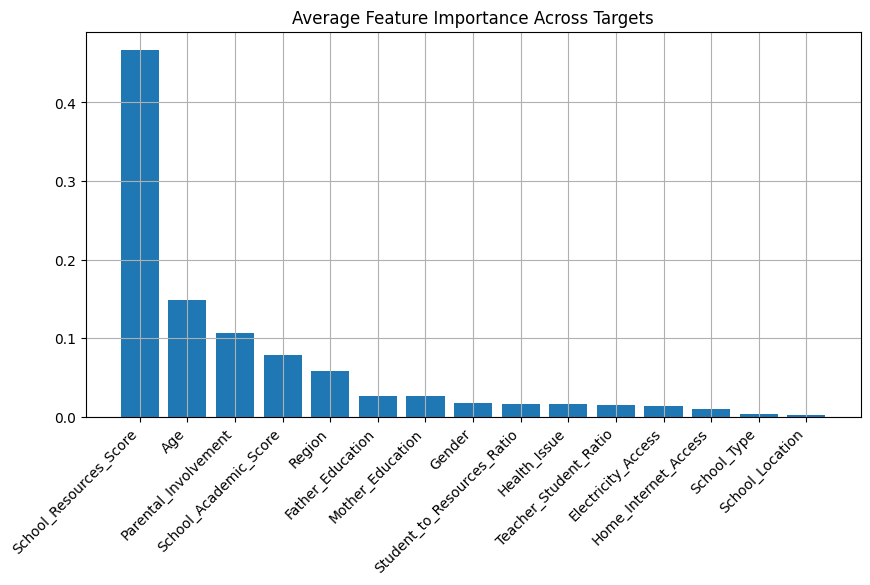

In [42]:
plt.figure(figsize=(10,5))
plt.bar(avg_imp_table["Predictor"], avg_imp_table["AverageImportance"])
plt.xticks(rotation=45, ha="right")
plt.title("Average Feature Importance Across Targets")
plt.grid(True)
plt.show()

The plot of average feature importance across all three targets clearly highlights **School_Resources_Score** as the most influential contextual factor impacting student academic performance. Following this, **Age**, **Parental_Involvement**, and **School_Academic_Score** also demonstrate significant average importance. This suggests that the availability and quality of school resources, student age, parental engagement, and the overall academic standing of the school are key drivers of student success.

## Model 2: Gradient Boosting
## Context + Behavioural Features

This second model extends the contextual framework by introducing engineered behavioural variables derived from attendance, homework completion, and class participation across grade levels.

In [43]:
# Find behavioural columns
attendance_vars = [c for c in df.columns if "Attendance" in c]
homework_vars = [c for c in df.columns if "Homework_Completion" in c]
particip_vars = [c for c in df.columns if "Class_Participation" in c]

print("Attendance vars:", len(attendance_vars))
print("Homework vars:", len(homework_vars))
print("Participation vars:", len(particip_vars))

Attendance vars: 120
Homework vars: 120
Participation vars: 120


In [44]:
Attendance_Mean = df[attendance_vars].mean(axis=1)
Homework_Mean = df[homework_vars].mean(axis=1)
Participation_Mean = df[particip_vars].mean(axis=1)

Engagement_Index = pd.concat([
    Attendance_Mean,
    Homework_Mean,
    Participation_Mean
], axis=1).mean(axis=1)

## Behavioural Feature Engineering

Repeated student activity variables are compressed into summary indicators to reduce dimensionality while preserving learning behaviour patterns.

In [45]:
D2 = D[predictor_names + target_names].copy()

D2["Attendance_Mean"] = Attendance_Mean
D2["Homework_Mean"] = Homework_Mean
D2["Participation_Mean"] = Participation_Mean
D2["Engagement_Index"] = Engagement_Index

In [46]:
# Encode categoricals
for col in D2.columns:
    if D2[col].dtype == "object":
        D2[col] = pd.factorize(D2[col])[0]

# Fill missing values
D2 = D2.fillna(D2.median(numeric_only=True))

## Gradient Boosting Regression

A boosting model is trained because it often outperforms Random Forest when engineered behavioural features are available.

Total_Test_Score RMSE: 406.68128944743046 R2: 0.7850990333420392


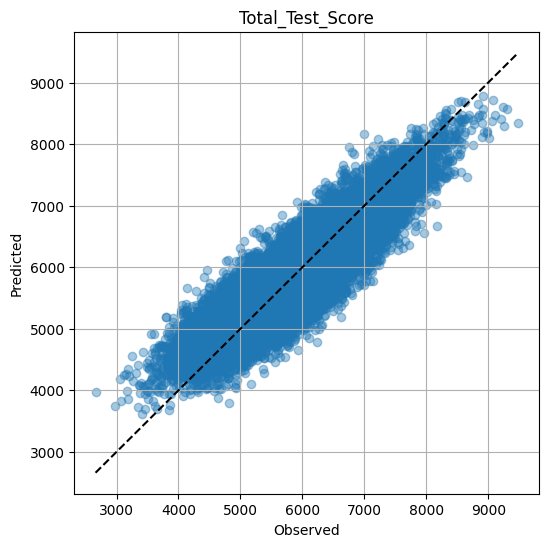

Overall_Average RMSE: 3.711065686989661 R2: 0.7869953017658947


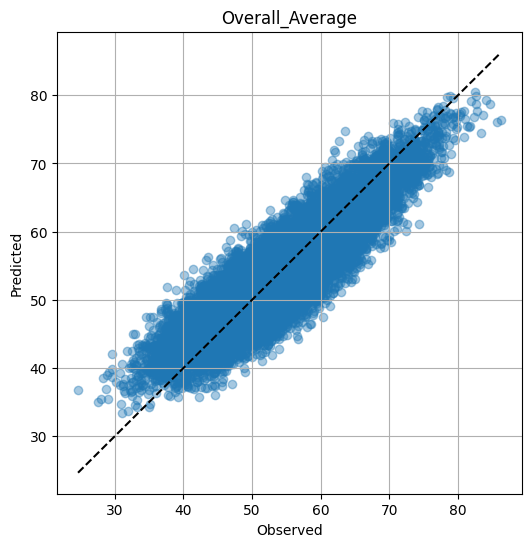

Total_National_Exam_Score RMSE: 32.26820581582856 R2: 0.40376918233601666


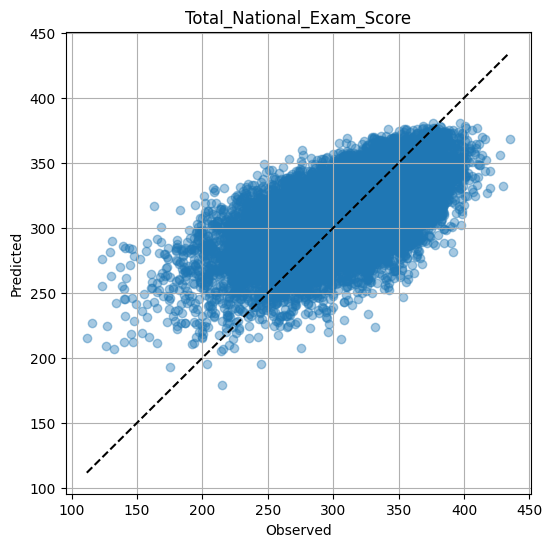

In [47]:
from sklearn.ensemble import GradientBoostingRegressor

results2 = []

predictor_cols2 = [c for c in D2.columns if c not in target_names]

# Initialize DataFrame to store feature importances for Model 2
importance_all_model2 = pd.DataFrame(index=predictor_cols2)

for target in target_names:

    X = D2[predictor_cols2]
    y = D2[target]

    X_train, X_test, y_train, y_test = train_test_split(
        X, y, test_size=0.20, random_state=42
    )

    model = GradientBoostingRegressor(
        n_estimators=300,
        learning_rate=0.05,
        random_state=42
    )

    model.fit(X_train, y_train)

    y_pred = model.predict(X_test)

    rmse = np.sqrt(mean_squared_error(y_test, y_pred))
    r2 = r2_score(y_test, y_pred)

    results2.append({
        "Target": target,
        "TrainN": len(X_train),
        "TestN": len(X_test),
        "RMSE": rmse,
        "R2": r2
    })

    print(target, "RMSE:", rmse, "R2:", r2)

    # Store feature importances for the current target
    importance_all_model2[target] = model.feature_importances_

    plt.figure(figsize=(6,6))
    plt.scatter(y_test, y_pred, alpha=0.4)
    plt.xlabel("Observed")
    plt.ylabel("Predicted")
    plt.title(target)

    mn = min(y_test.min(), y_pred.min())
    mx = max(y_test.max(), y_pred.max())
    plt.plot([mn,mx],[mn,mx],"k--")
    plt.grid(True)
    plt.show()

In [48]:
results2_table = pd.DataFrame(results2)
results2_table

,Target,TrainN,TestN,RMSE,R2
0,Total_Test_Score,80000,20000,406.681289,0.785099
1,Overall_Average,80000,20000,3.711066,0.786995
2,Total_National_Exam_Score,80000,20000,32.268206,0.403769


In [49]:
results2_table.to_csv(f"{out_dir}/Model_2_performance", index=False)

## **Key Observations and Interpretation:**

Significant Performance Boost with Behavioural Features: For all three target variables, Model 2 (which includes engineered behavioural features like attendance, homework completion, and participation) shows a substantial improvement in R² scores compared to Model 1. This strongly suggests that student engagement and behavioural patterns are crucial predictors of academic success.

### **Total_Test_Score and Overall_Average:**

Both models performed reasonably well on these internal academic metrics. However, Model 2's R² of approximately 0.78 for both indicates that nearly 78% of the variance in these scores can now be explained by the contextual and behavioural factors combined. This is a very strong predictive capability, suggesting that for these internal assessments, the models are highly effective.
The RMSE also dropped significantly, meaning the average prediction error is much lower in Model 2.

### **Total_National_Exam_Score:**

This was the most challenging target for Model 1, with a very low R² of 0.096, indicating that contextual factors alone explained very little of the variance in national exam scores.
However, with the addition of behavioural features, Model 2's R² jumped to 0.404. While still lower than the other two targets, this is a remarkable improvement. It suggests that while national exams might be influenced by unique factors (like high-stakes pressure or specific exam preparation strategies), active student engagement (attendance, homework, participation) plays a much more significant role than just background context. The model can now explain over 40% of the variance, which is a solid step forward.


### **Conclusion:**

The comparison clearly demonstrates the added value of incorporating behavioural data. While contextual factors provide a baseline understanding, student engagement variables are essential for building more accurate and robust predictive models of academic performance in this Ethiopian context. The Gradient Boosting Regressor further leveraged these features to achieve better performance across the board.

## Average Predictor Importance for Model 2

In [50]:
avg_importance_model2 = importance_all_model2.mean(axis=1)

avg_imp_table_model2 = pd.DataFrame({
    "Predictor": predictor_cols2,
    "AverageImportance": avg_importance_model2.values
}).sort_values("AverageImportance", ascending=False)

avg_imp_table_model2

,Predictor,AverageImportance
11,School_Resources_Score,0.463171
18,Engagement_Index,0.272761
13,School_Academic_Score,0.095874
16,Homework_Mean,0.054053
17,Participation_Mean,0.050337
15,Attendance_Mean,0.032745
5,Parental_Involvement,0.014015
12,Student_to_Resources_Ratio,0.008425
10,Teacher_Student_Ratio,0.006172
2,Health_Issue,0.001057


In [51]:
avg_imp_table_model2.to_csv(f"{out_dir}/Model_2_feature_importance.csv", index=False)

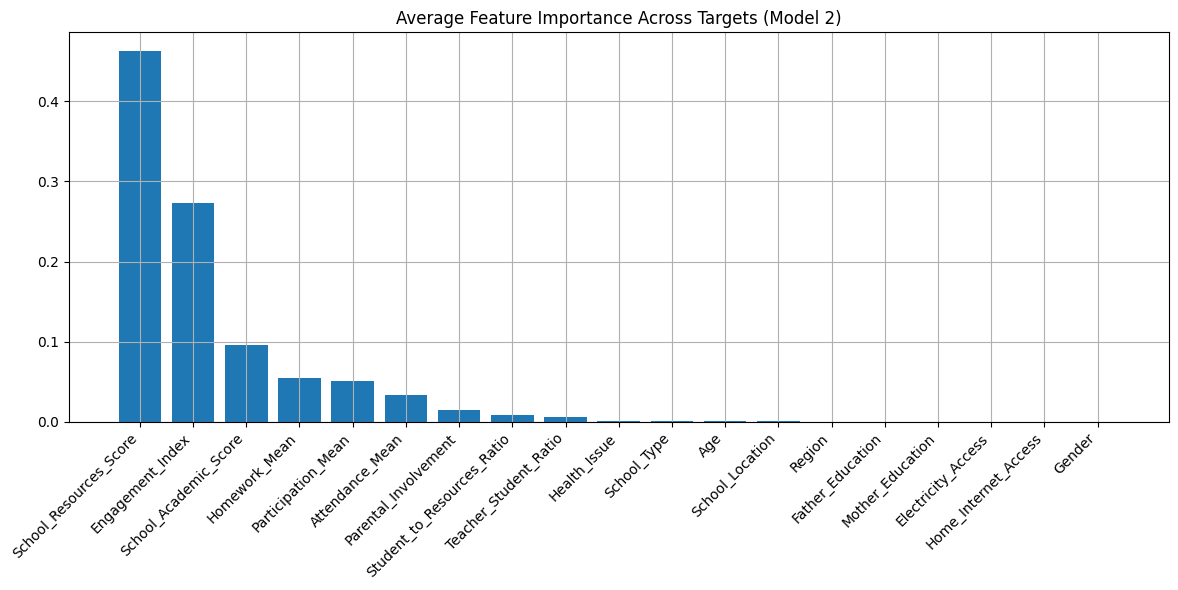

In [52]:
plt.figure(figsize=(12,6))
plt.bar(avg_imp_table_model2["Predictor"], avg_imp_table_model2["AverageImportance"])
plt.xticks(rotation=45, ha="right")
plt.title("Average Feature Importance Across Targets (Model 2)")
plt.grid(True)
plt.tight_layout()
plt.show()

### Interpretation of Average Predictor Importance for Model 2

This plot shows the average importance of each predictor variable across the three target variables when using the Gradient Boosting Regressor with both contextual and the newly engineered behavioral features. We can now identify which factors, including student engagement, are most influential in predicting academic performance.


**School_Resources_Score Remains Dominant**: Similar to Model 1, School_Resources_Score is still the most influential predictor with a very high average importance of 0.463. This emphasizes that the quality and availability of school resources are paramount for student academic success.

**Behavioural Features Ascend to Prominence:** The most striking change is the dramatic rise of the newly engineered behavioural features:

Engagement_Index is now the second most important predictor with an average importance of 0.273.

Homework_Mean and Participation_Mean also show significant importance, ranking 4th and 5th respectively.

Attendance_Mean also contributes as an important feature.
This clearly demonstrates that combining and aggregating student behaviour into an Engagement_Index (and its components) provides substantial predictive power for academic outcomes.

**School_Academic_Score** remains a strong predictor, ranking 3rd, reinforcing the idea that the overall academic environment of the school plays a crucial role.

**Shift in Importance for Other Features:** While Parental_Involvement remains important, its relative rank has decreased compared to Model 1 due to the higher importance of behavioural features. Interestingly, Age, which was the second most important feature in Model 1, now has very low importance in Model 2. This suggests that once student engagement and detailed school resources are accounted for, the direct influence of 'Age' on overall academic performance becomes less pronounced.

**Overall Interpretation:**

Model 2 confirms the critical role of school resources and academic environment, but, more importantly, it vividly illustrates the indispensable value of student behavioural factors. The Engagement_Index, alongside its components, provides a powerful signal for predicting academic success, especially when using a robust model like Gradient Boosting. The improved R² scores across all targets, particularly for Total_National_Exam_Score, directly correlate with the predictive strength of these behavioural features.

This analysis strongly suggests that active student engagement is a key driver of academic success, even more so than some contextual factors, once other school-level variables are considered. It highlights that interventions focusing on improving student engagement, homework completion, and class participation could have a significant positive impact on student performance in Ethiopia.

## **11. Hypothesis Testing**

## Hypothesis Testing: Do Categorical Factors Influence Student Performance?

In addition to predictive machine learning models, statistical hypothesis testing was conducted to examine whether average student performance differs significantly across important categorical groups.

The selected factors were:

- **Region**
- **Health_Issue**
- **School_Type**

These variables are categorical in nature, meaning Pearson correlation is not the most appropriate method for measuring their relationship with continuous academic outcomes. Therefore, a **One-Way ANOVA (Analysis of Variance)** was used, as all three categorical variables have 3 or more groups and our target variables are numeric.

### Academic Performance Targets Tested

The following three outcome variables were analyzed:

- `Total_Test_Score`
- `Overall_Average`
- `Total_National_Exam_Score`

### Hypotheses

For each factor-target combination:

- **Null Hypothesis (H₀):** All group means are equal.  
  (e.g., average scores are the same across all regions)

- **Alternative Hypothesis (H₁):** At least one group mean is different.

### Decision Rule

- If **p-value < 0.05** → Reject H₀ (statistically significant difference exists)
- If **p-value ≥ 0.05** → Fail to reject H₀

This analysis helps identify whether student outcomes vary systematically across regions, school types, or health conditions beyond what prediction models alone can show.

In [53]:
# ==========================================
# ONE-WAY ANOVA FOR ALL 3 FACTORS × 3 TARGETS
# DataFrame = D
# ==========================================

import pandas as pd
from scipy.stats import f_oneway

# Factors (categorical predictors)
factors = ['Region', 'Health_Issue', 'School_Type']

# Targets (continuous outcomes)
targets = [
    'Total_Test_Score',
    'Overall_Average',
    'Total_National_Exam_Score'
]

results = []

for factor in factors:
    for target in targets:

        # Create groups for ANOVA
        groups = [
            group[target].dropna().values
            for name, group in D.groupby(factor)
            if len(group[target].dropna()) > 1
        ]

        # Run ANOVA
        f_stat, p_value = f_oneway(*groups)

        # Save result
        results.append({
            'Factor': factor,
            'Target': target,
            'F_statistic': round(f_stat, 4),
            'p_value': p_value,
            'Significant (0.05)': 'Yes' if p_value < 0.05 else 'No'
        })

# Convert to table
anova_results = pd.DataFrame(results)

# Display
anova_results

,Factor,Target,F_statistic,p_value,Significant (0.05)
0,Region,Total_Test_Score,62.4804,3.783799e-152,Yes
1,Region,Overall_Average,62.2520,1.448529e-151,Yes
2,Region,Total_National_Exam_Score,6.2805,3.167071e-11,Yes
3,Health_Issue,Total_Test_Score,30.2084,2.827448e-53,Yes
4,Health_Issue,Overall_Average,30.0383,5.947677e-53,Yes
5,Health_Issue,Total_National_Exam_Score,1.0325,4.107035e-01,No
6,School_Type,Total_Test_Score,4051.4271,0.000000e+00,Yes
7,School_Type,Overall_Average,4068.6037,0.000000e+00,Yes
8,School_Type,Total_National_Exam_Score,238.9208,1.372495e-204,Yes


## Interpretation of Hypothesis Testing Results

The One-Way ANOVA results show that several categorical factors are significantly associated with student academic performance.

### 1. Region

Region showed a statistically significant relationship with all three academic outcomes:

- Total_Test_Score (p < 0.001)
- Overall_Average (p < 0.001)
- Total_National_Exam_Score (p < 0.001)

This indicates that student performance differs across Ethiopian regions. The strongest regional differences were observed in internal academic measures (Total_Test_Score and Overall_Average), while smaller but still significant differences were found for the national examination score.

This may reflect variation in educational resources, infrastructure, socioeconomic conditions, teacher availability, and learning environments across regions.



### 2. Health_Issue

Health status showed a statistically significant relationship with:

- Total_Test_Score (p < 0.001)
- Overall_Average (p < 0.001)

However, Health_Issue was **not statistically significant** for Total_National_Exam_Score (p = 0.411).

This suggests that student health conditions may influence day-to-day academic performance and continuous assessment outcomes, but did not show a measurable difference in national exam scores within this dataset.

One possible explanation is that national examinations may depend more heavily on short-term exam preparation, subject mastery, or external factors not captured by health category alone.



### 3. School_Type

School_Type produced the strongest statistical differences among all tested factors.

It was highly significant for:

- Total_Test_Score (p < 0.001)
- Overall_Average (p < 0.001)
- Total_National_Exam_Score (p < 0.001)

The extremely large F-statistics indicate substantial differences in academic outcomes across school categories.

This suggests that school environment, management model, resources, instructional quality, and institutional support may play a major role in shaping student achievement.



## Overall Conclusion

The hypothesis testing results indicate that **Region** and **School_Type** are consistently associated with student performance across all academic measures, while **Health_Issue** appears more related to internal academic outcomes than national examination performance.

Among all tested variables, **School_Type emerged as the strongest differentiating factor**, suggesting that school-level conditions may have the greatest influence on student success in this dataset.

## Group Performance Rankings: Region and School Type

After identifying statistically significant differences through ANOVA, the next step is to determine **which groups perform highest and lowest on average**.

While hypothesis testing confirms that differences exist, ranking group means provides more practical insight for decision-making and interpretation.

This section compares average academic performance across:

- **Region**
- **School_Type**

Using the following outcome measures:

- `Total_Test_Score`
- `Overall_Average`
- `Total_National_Exam_Score`

The goal is to identify top-performing and lower-performing groups within this dataset, helping translate statistical significance into meaningful educational insights.

In [54]:
# ===============================
# REGION PERFORMANCE RANKINGS
# ===============================

region_results = df.groupby("Region")[[
    "Total_Test_Score",
    "Overall_Average",
    "Total_National_Exam_Score"
]].mean().round(2)

region_results = region_results.sort_values("Overall_Average", ascending=False)

print("Average Performance by Region")
display(region_results)

Average Performance by Region


,Total_Test_Score,Overall_Average,Total_National_Exam_Score
Region,,,
Addis Ababa,6002.09,55.06,317.45
Harari,5894.23,54.08,315.92
Dire Dawa,5883.00,53.98,315.92
South West Ethiopia,5826.68,53.46,315.27
Amhara,5799.33,53.21,314.11
Oromia,5787.58,53.10,314.41
Gambela,5774.64,52.99,314.20
SNNP,5769.39,52.93,314.41
Afar,5753.73,52.78,312.89


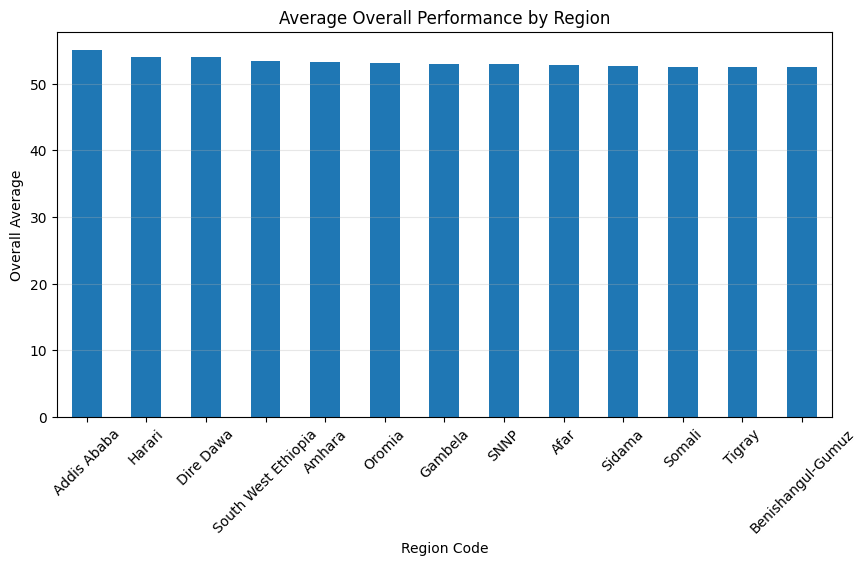

In [55]:
# Bar chart: Overall Average by Region

import matplotlib.pyplot as plt

plt.figure(figsize=(10,5))
region_results["Overall_Average"].plot(kind="bar")
plt.title("Average Overall Performance by Region")
plt.ylabel("Overall Average")
plt.xlabel("Region Code")
plt.xticks(rotation=45)
plt.grid(axis='y', alpha=0.3)
plt.show()

## Interpretation of Regional Performance Rankings

The regional comparison reveals noticeable differences in average student academic performance across Ethiopia.

### Highest Performing Region

**Addis Ababa** recorded the strongest performance across all major academic indicators:

- Total_Test_Score: **6002.09**
- Overall_Average: **55.06**
- Total_National_Exam_Score: **317.45**

This may reflect stronger educational infrastructure, greater school access, better learning resources, and more urban academic opportunities.

### Other Strong Performing Regions

Following Addis Ababa, the next highest-performing regions were:

- **Harari**
- **Dire Dawa**
- **South West Ethiopia**

These regions also showed above-average outcomes across the three performance measures.

### Lower Performing Regions

The lowest average Overall_Average scores were observed in:

- **Benishangul-Gumuz**
- **Tigray**
- **Somali**

Although the differences are moderate rather than extreme, the pattern suggests unequal educational outcomes across regions.

### Performance Gap

The difference between the highest and lowest Overall_Average was:

- **55.06 - 52.49 = 2.57 points**

This indicates measurable regional disparity within the dataset.

### National Examination Results

Regional differences in `Total_National_Exam_Score` were smaller than internal academic scores, suggesting that national exams may reduce some regional variation through standardization.

### Overall Conclusion

The results suggest that **regional context matters** for academic achievement. Differences in infrastructure, socioeconomic conditions, school quality, teacher distribution, and urban-rural opportunities may help explain these performance gaps.

However, these findings should be interpreted as dataset-based averages rather than judgments about student ability.

In [56]:
# ===============================
# SCHOOL TYPE PERFORMANCE
# ===============================

school_results = df.groupby("School_Type")[[
    "Total_Test_Score",
    "Overall_Average",
    "Total_National_Exam_Score"
]].mean().round(2)

school_results = school_results.sort_values("Overall_Average", ascending=False)

print("Average Performance by School Type")
display(school_results)

Average Performance by School Type


,Total_Test_Score,Overall_Average,Total_National_Exam_Score
School_Type,,,
Private,6730.34,61.75,326.59
NGO-operated,5855.15,53.73,312.08
Faith-based,5849.86,53.67,315.55
Public,5700.42,52.30,313.44
Community,5306.74,48.67,310.86


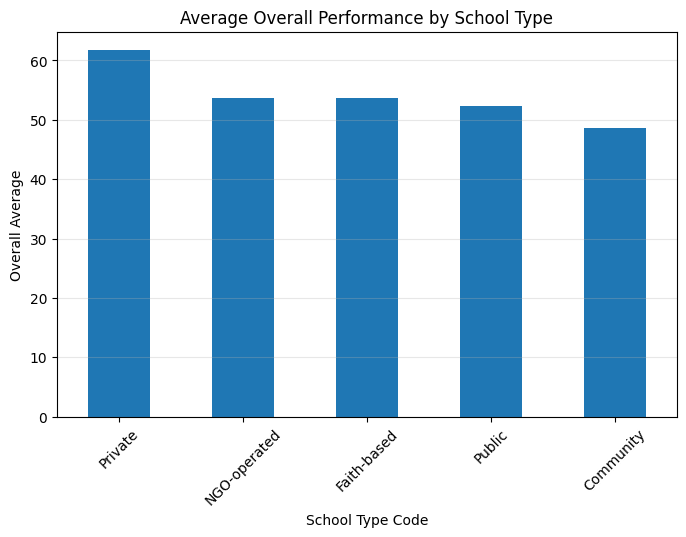

In [57]:
# Bar chart: Overall Average by School Type

plt.figure(figsize=(8,5))
school_results["Overall_Average"].plot(kind="bar")
plt.title("Average Overall Performance by School Type")
plt.ylabel("Overall Average")
plt.xlabel("School Type Code")
plt.xticks(rotation=45)
plt.grid(axis='y', alpha=0.3)
plt.show()

## Interpretation of School Type Performance Rankings

The comparison across school categories shows some of the clearest academic differences in the entire dataset.

### Highest Performing School Type

**Private schools** achieved the strongest results across all three outcome measures:

- Total_Test_Score: **6730.34**
- Overall_Average: **61.75**
- Total_National_Exam_Score: **326.59**

Private schools outperformed every other category by a substantial margin, suggesting potential advantages such as lower class sizes, stronger resources, closer supervision, or additional academic support.

### Mid-Level Performing School Types

The next strongest categories were:

- **NGO-operated schools**
- **Faith-based schools**

Both groups performed above Public and Community schools, with relatively similar averages.

### Lower Performing School Types

The lowest results were observed in:

- **Public schools**
- **Community schools**

Community schools recorded the weakest averages across all outcomes.

### Performance Gap

The difference in Overall_Average between the highest and lowest school types was:

- **61.75 - 48.67 = 13.08 points**

This is a very large gap and much greater than the regional gap observed earlier.

### National Examination Scores

Even in standardized national exams, Private schools remained highest:

- Private: **326.59**
- Community: **310.86**

This suggests that school environment differences extend beyond internal assessments.

### Overall Conclusion

Among all categorical factors examined, **School_Type appears to be one of the strongest drivers of academic performance** in this dataset.

The findings suggest that institutional conditions such as resources, management quality, teaching support, and learning environment may play a major role in student outcomes.

These results describe average differences within the dataset and should not be interpreted as fixed judgments about individual students or schools.

In [58]:
# Top and Bottom Groups

print("Top Performing Region:")
display(region_results.head(1))

print("Lowest Performing Region:")
display(region_results.tail(1))

print("Top Performing School Type:")
display(school_results.head(1))

print("Lowest Performing School Type:")
display(school_results.tail(1))

Top Performing Region:


,Total_Test_Score,Overall_Average,Total_National_Exam_Score
Region,,,
Addis Ababa,6002.09,55.06,317.45


Lowest Performing Region:


,Total_Test_Score,Overall_Average,Total_National_Exam_Score
Region,,,
Benishangul-Gumuz,5720.28,52.49,313.72


Top Performing School Type:


,Total_Test_Score,Overall_Average,Total_National_Exam_Score
School_Type,,,
Private,6730.34,61.75,326.59


Lowest Performing School Type:


,Total_Test_Score,Overall_Average,Total_National_Exam_Score
School_Type,,,
Community,5306.74,48.67,310.86


## Independent Two-Sample t-Test

To complement the machine learning and ANOVA analyses, an independent two-sample t-test was conducted to compare mean academic performance between two-group variables.

Unlike ANOVA, which compares three or more groups, the t-test is appropriate when comparing exactly two categories.

### Variables Tested

1. **Gender** (Male vs Female)  
2. **Home_Internet_Access** (Access vs No Access)

### Outcome Variable

The selected academic outcome was:

- `Total_National_Exam_Score`

This target was chosen because it represents a standardized national assessment and provides a strong benchmark for student achievement.

### Hypotheses

For each test:

- **Null Hypothesis (H₀):** The two group means are equal.
- **Alternative Hypothesis (H₁):** The two group means are different.

### Decision Rule

- If **p-value < 0.05** → Reject H₀  
- If **p-value ≥ 0.05** → Fail to reject H₀

Welch’s t-test was used to account for possible differences in variance between groups.

In [59]:
from scipy.stats import ttest_ind

# ===============================
# 1. Gender vs National Exam Score
# ===============================

male = D[D["Gender"] == 1]["Total_National_Exam_Score"]
female = D[D["Gender"] == 0]["Total_National_Exam_Score"]

t_stat1, p_val1 = ttest_ind(male, female, equal_var=False)

print("Gender t-test")
print("Male Mean   :", round(male.mean(),2))
print("Female Mean :", round(female.mean(),2))
print("t-statistic :", round(t_stat1,4))
print("p-value     :", p_val1)

print("-"*50)

# ===============================
# 2. Internet Access vs National Exam Score
# ===============================

internet_yes = D[D["Home_Internet_Access"] == 1]["Total_National_Exam_Score"]
internet_no  = D[D["Home_Internet_Access"] == 0]["Total_National_Exam_Score"]

t_stat2, p_val2 = ttest_ind(internet_yes, internet_no, equal_var=False)

print("Internet Access t-test")
print("Yes Mean :", round(internet_yes.mean(),2))
print("No Mean  :", round(internet_no.mean(),2))
print("t-statistic :", round(t_stat2,4))
print("p-value     :", p_val2)

Gender t-test
Male Mean   : 314.69
Female Mean : 314.58
t-statistic : 0.4393
p-value     : 0.660421620450491
--------------------------------------------------
Internet Access t-test
Yes Mean : 315.51
No Mean  : 314.33
t-statistic : 3.9186
p-value     : 8.918170848137593e-05


# T-Test Interpretation Results

## 1. Gender T-Test (Male vs Female)

- **Male Mean:** 314.69  
- **Female Mean:** 314.58  
- **t-statistic:** 0.4393  
- **p-value:** 0.6604  

### Interpretation:
There is **no statistically significant difference** between male and female students’ scores.

- The p-value (0.6604) is much greater than 0.05, meaning the result is not statistically significant.
- The difference in means (314.69 vs 314.58) is extremely small and likely due to random variation.
- The low t-statistic (0.4393) shows that the difference between the two groups is minimal.

### Conclusion:
**Gender does not have a significant effect** on student performance of national exam.



## 2. Internet Access T-Test (Yes vs No)

- **Internet Access (Yes) Mean:** 315.51  
- **Internet Access (No) Mean:** 314.33  
- **t-statistic:** 3.9186  
- **p-value:** 0.00008918 (8.918 × 10⁻⁵)

### Interpretation:
There is a **statistically significant difference** between students with and without internet access.

- The p-value is far below 0.05, indicating a highly significant result.
- Students with internet access scored higher on average (about 1.18 points higher).
- The relatively large t-statistic (3.9186) confirms a strong difference between the two groups.

### Conclusion:
**Internet access has a significant positive association** with student performance in the national exam.



## **Overall Conclusion**

- Gender is **not a significant predictor** of student performance.
- Internet access is a **significant factor** and is associated with higher academic performance.

## **Final Discussion and Conclusion**  
## Beyond Scores: What Really Shapes Student Success?

Two years ago, I was one of the many Grade 12 students sitting for the Ethiopian national entrance examination. Like thousands of others, I felt the pressure, uncertainty, and weight of a single score that seemed to define the future. At that time, one question stayed in my mind:

**Why do some students perform better than others?**  
Is it talent? Family support? School quality? Region? Health? Resources? Effort?

This project was born from that question.

Using a large dataset of **100,000 Ethiopian student records** with hundreds of variables, this study aimed to move beyond assumptions and use data science to understand the real drivers of academic performance.

Rather than simply predicting scores, the deeper purpose was to uncover the system behind performance.

---

## 1. The First Discovery: Performance Is Not Random

The early correlation analysis immediately showed that student outcomes are strongly connected to environmental conditions.

The strongest positive relationships with academic success were:

- **School_Resources_Score**
- **School_Academic_Score**
- **School_Location**
- **Parental_Involvement**

Negative relationships were observed with:

- **Teacher_Student_Ratio**
- **Student_to_Resources_Ratio**

This tells an important story:

Students do not learn in isolation.  
They learn inside systems.

When resources increase, performance rises.  
When overcrowding increases, performance declines.

This shifts the conversation away from blaming students and toward understanding the environments around them.

---

## 2. Model 1: Context Alone Can Explain a Lot

The first machine learning model used only contextual variables:

- Family background  
- School conditions  
- Region  
- Gender  
- Infrastructure  
- Health

Even without behavioral data, the model explained:

- **57.3%** of Total Test Score variation  
- **57.5%** of Overall Average variation

That is a strong result.

It means that before a student even enters the classroom each morning, a large portion of academic outcomes is already shaped by surrounding conditions.

Where a student studies, what resources the school has, how involved parents are, and how many students share resources all matter greatly.

For national exam scores, however, contextual variables explained only:

- **9.7%** of variation

This was the first major turning point of the study.

It suggested that while context shapes continuous academic performance, national exams depend on something more.

---

## 3. Model 2: The Missing Ingredient Was Behavior

The second model introduced behavioral features:

- Attendance  
- Homework completion  
- Class participation  
- Engagement index

Once these were added, predictive power increased dramatically:

### Total Test Score

- Model 1: **57.3%**
- Model 2: **78.5%**

### Overall Average

- Model 1: **57.5%**
- Model 2: **78.7%**

### National Exam Score

- Model 1: **9.7%**
- Model 2: **40.4%**

This was the clearest message in the project:

## Good conditions matter.  
## But engagement transforms conditions into results.

A supportive home and well-funded school create opportunity.

But attendance, participation, and homework convert opportunity into achievement.

This is one of the strongest educational insights from the study.

---

## 4. The Human Story Behind the Numbers

Feature importance analysis consistently ranked the following among the strongest predictors:

- **School_Resources_Score**
- **Engagement_Index**
- **School_Academic_Score**
- **Parental_Involvement**

These are not abstract numbers.

They represent:

- Whether a student has books, classrooms, and materials  
- Whether they regularly attend class  
- Whether they complete assignments  
- Whether parents are involved in learning

In short:

Success was not driven mainly by gender or age.

It was driven by support systems and habits.

---

## 5. Regional Differences Exist

ANOVA testing confirmed statistically significant differences across regions for all academic targets.

The highest average regional performance came from:

### Addis Ababa

While lower averages were observed in some developing regions.

This likely reflects unequal access to:

- Educational infrastructure  
- Qualified teachers  
- Urban opportunities  
- Stable learning environments

The implication is clear:

Educational inequality can also be geographic inequality.

Where a student is born may influence the quality of education they receive.

---

## 6. School Type Was One of the Strongest Factors

Among all categorical comparisons, school type showed the largest differences.

### Highest Performing:

- **Private Schools**

### Lowest Performing:

- **Community Schools**

The gap in overall average exceeded **13 points**, which is substantial.

This suggests that institutional quality, management systems, learning culture, and available resources strongly shape student outcomes.

This does **not** mean one student group is more capable than another.

It means environments differ.

And environments matter.

---

## 7. Gender Did Not Meaningfully Differ

The t-test comparing male and female national exam scores found:

- Male Mean = 314.69  
- Female Mean = 314.58  
- p = 0.660

No significant difference.

This is an important result.

It challenges simplistic narratives about gender performance and suggests that opportunity and environment may matter far more than gender itself.

---

## 8. Internet Access Did Matter

Students with internet access scored significantly higher than those without it.

This likely reflects modern educational advantages:

- Online learning materials  
- Research access  
- Practice resources  
- Digital exposure

In the modern world, internet access is increasingly part of educational equity.

---

## 9. Why Linear Regression Underperformed

A baseline linear regression model explained only:

- **10.7%** of national exam score variation

This indicates that educational performance is not governed by simple straight-line relationships.

Instead, it is nonlinear, layered, and interactive.

That is why Random Forest and Gradient Boosting performed far better.

Education is complex.

The models confirmed it.

---

## 10. Final Big Picture

This project began with one student wondering what affects success.

It ends with a broader answer:

Academic performance is not determined by a single trait or one exam day.

It is shaped by:

### Structural Factors

- School resources  
- Region  
- Infrastructure  
- Family education

### Institutional Factors

- School type  
- Academic environment  
- Teacher ratios

### Behavioral Factors

- Attendance  
- Homework  
- Participation  
- Engagement

And when these factors align, students thrive.

---

## Final Conclusion

If we want better student outcomes, we should not only ask students to work harder.

We should also ask:

- Are schools equipped?  
- Are classrooms manageable?  
- Are parents supported?  
- Are students engaged?  
- Are regions equally resourced?  
- Is technology accessible?

Because student success is not only built by effort.

It is built by systems.

And when systems improve, students rise with them.

---

## Closing Statement

This project used machine learning to predict scores.

But its deeper purpose was something more meaningful:

**To show that behind every score is a story and behind every story is a system that can be improved.**